In [1]:
import tkinter as tk
from tkinter import filedialog
import hyperspy.api as hs

In [2]:
# Create a function to select a file
def load_file():
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    file_path = filedialog.askopenfilename(
        title="Select a .hspy file",
        filetypes=[("All Files", "*.*"), ("Hyperspy Files", "*.hspy")]
    )

    if file_path:  # If a file is selected
        print("Selected file:", file_path)
        data = hs.load(file_path)
        print(data)
        return data  # Return loaded data

    return None  # If no file is selected

# Load the selected file
data = load_file()


Selected file: /workspaces/SAXS_WAXS/TEM_analysis files/S-C_0001.hspy
<Signal2D, title: , dimensions: (|4096, 4096)>


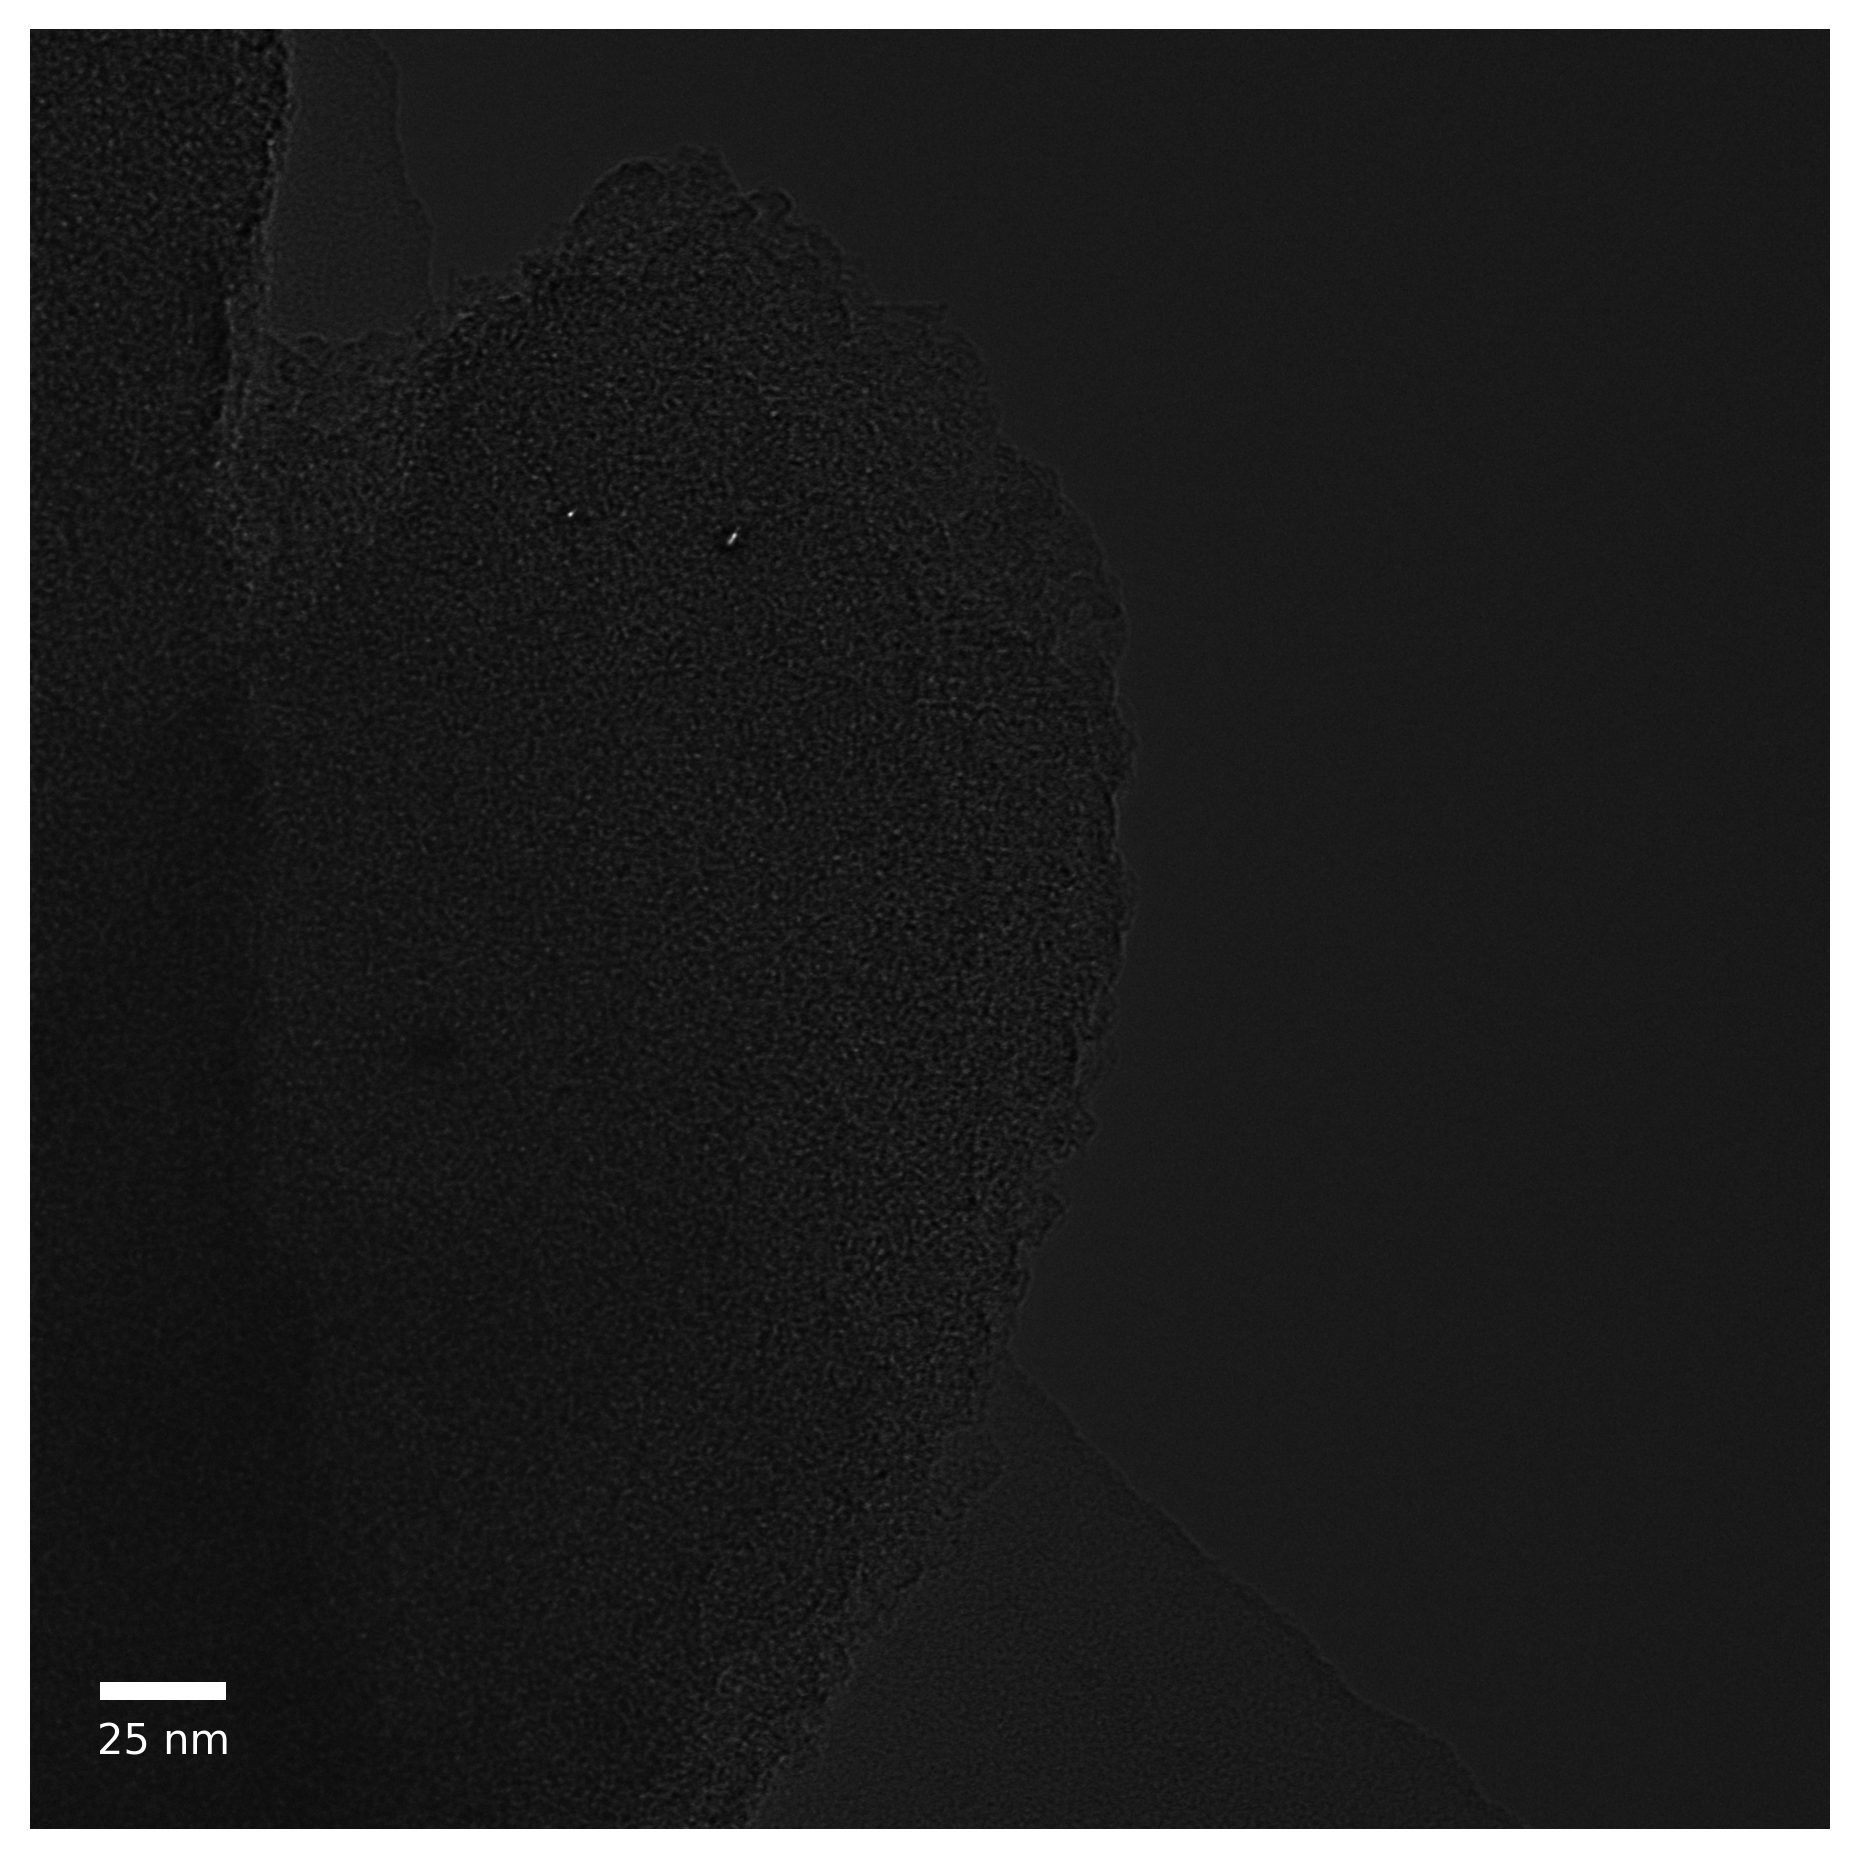

In [9]:
#%pip install matplotlib-scalebar
import hyperspy.api as hs
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar


# Get Pixel Size from Metadata (Stored in Meters)
pixel_size_m = data.axes_manager[0].scale  # This is in meters
pixel_size_nm = pixel_size_m * 1e9  # Convert meters to nanometers

# Create Figure & Plot Data Without Borders
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
fig.patch.set_alpha(0)  # Make figure background transparent
ax.set_xticks([])  # Remove X-axis
ax.set_yticks([])  # Remove Y-axis
ax.set_frame_on(False)  # Remove frame

# Remove unnecessary margins
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Plot the TEM image
ax.imshow(data.data, cmap="gray")

# Add Scale Bar inside the image with transparency
scalebar = ScaleBar(
    pixel_size_nm, "nm", 
    length_fraction=0.12,  # Reduce size slightly for better fit
    color="white",  # Scale bar color
    location="lower left",  # Move slightly inside
    scale_loc=None,  # No background box
    label_loc="bottom",  # Label at bottom
    frameon=False,  # No border/frame
    pad=1.5  # Moves scale bar slightly inward
)
ax.add_artist(scalebar)

# Show the final image with the scale bar
plt.show()


In [13]:
import numpy as np
import tifffile

img = data.data.astype(np.float32)

# Contrast stretch using robust limits (ignore outliers)
p1, p99 = np.percentile(img, (0.5, 99.5))   # try (0.5, 99.5) too
img_clip = np.clip(img, p1, p99)
img_norm = (img_clip - p1) / (p99 - p1 + 1e-12)

# Brighten midtones (gamma < 1 makes image brighter)
gamma = 0.1
img_gamma = img_norm ** gamma

out = (img_gamma * 255).astype(np.uint8)
tifffile.imwrite("test_normalized_bright.tiff", out)


ScaleBar dx/unit: 0.08757062146892657 nm


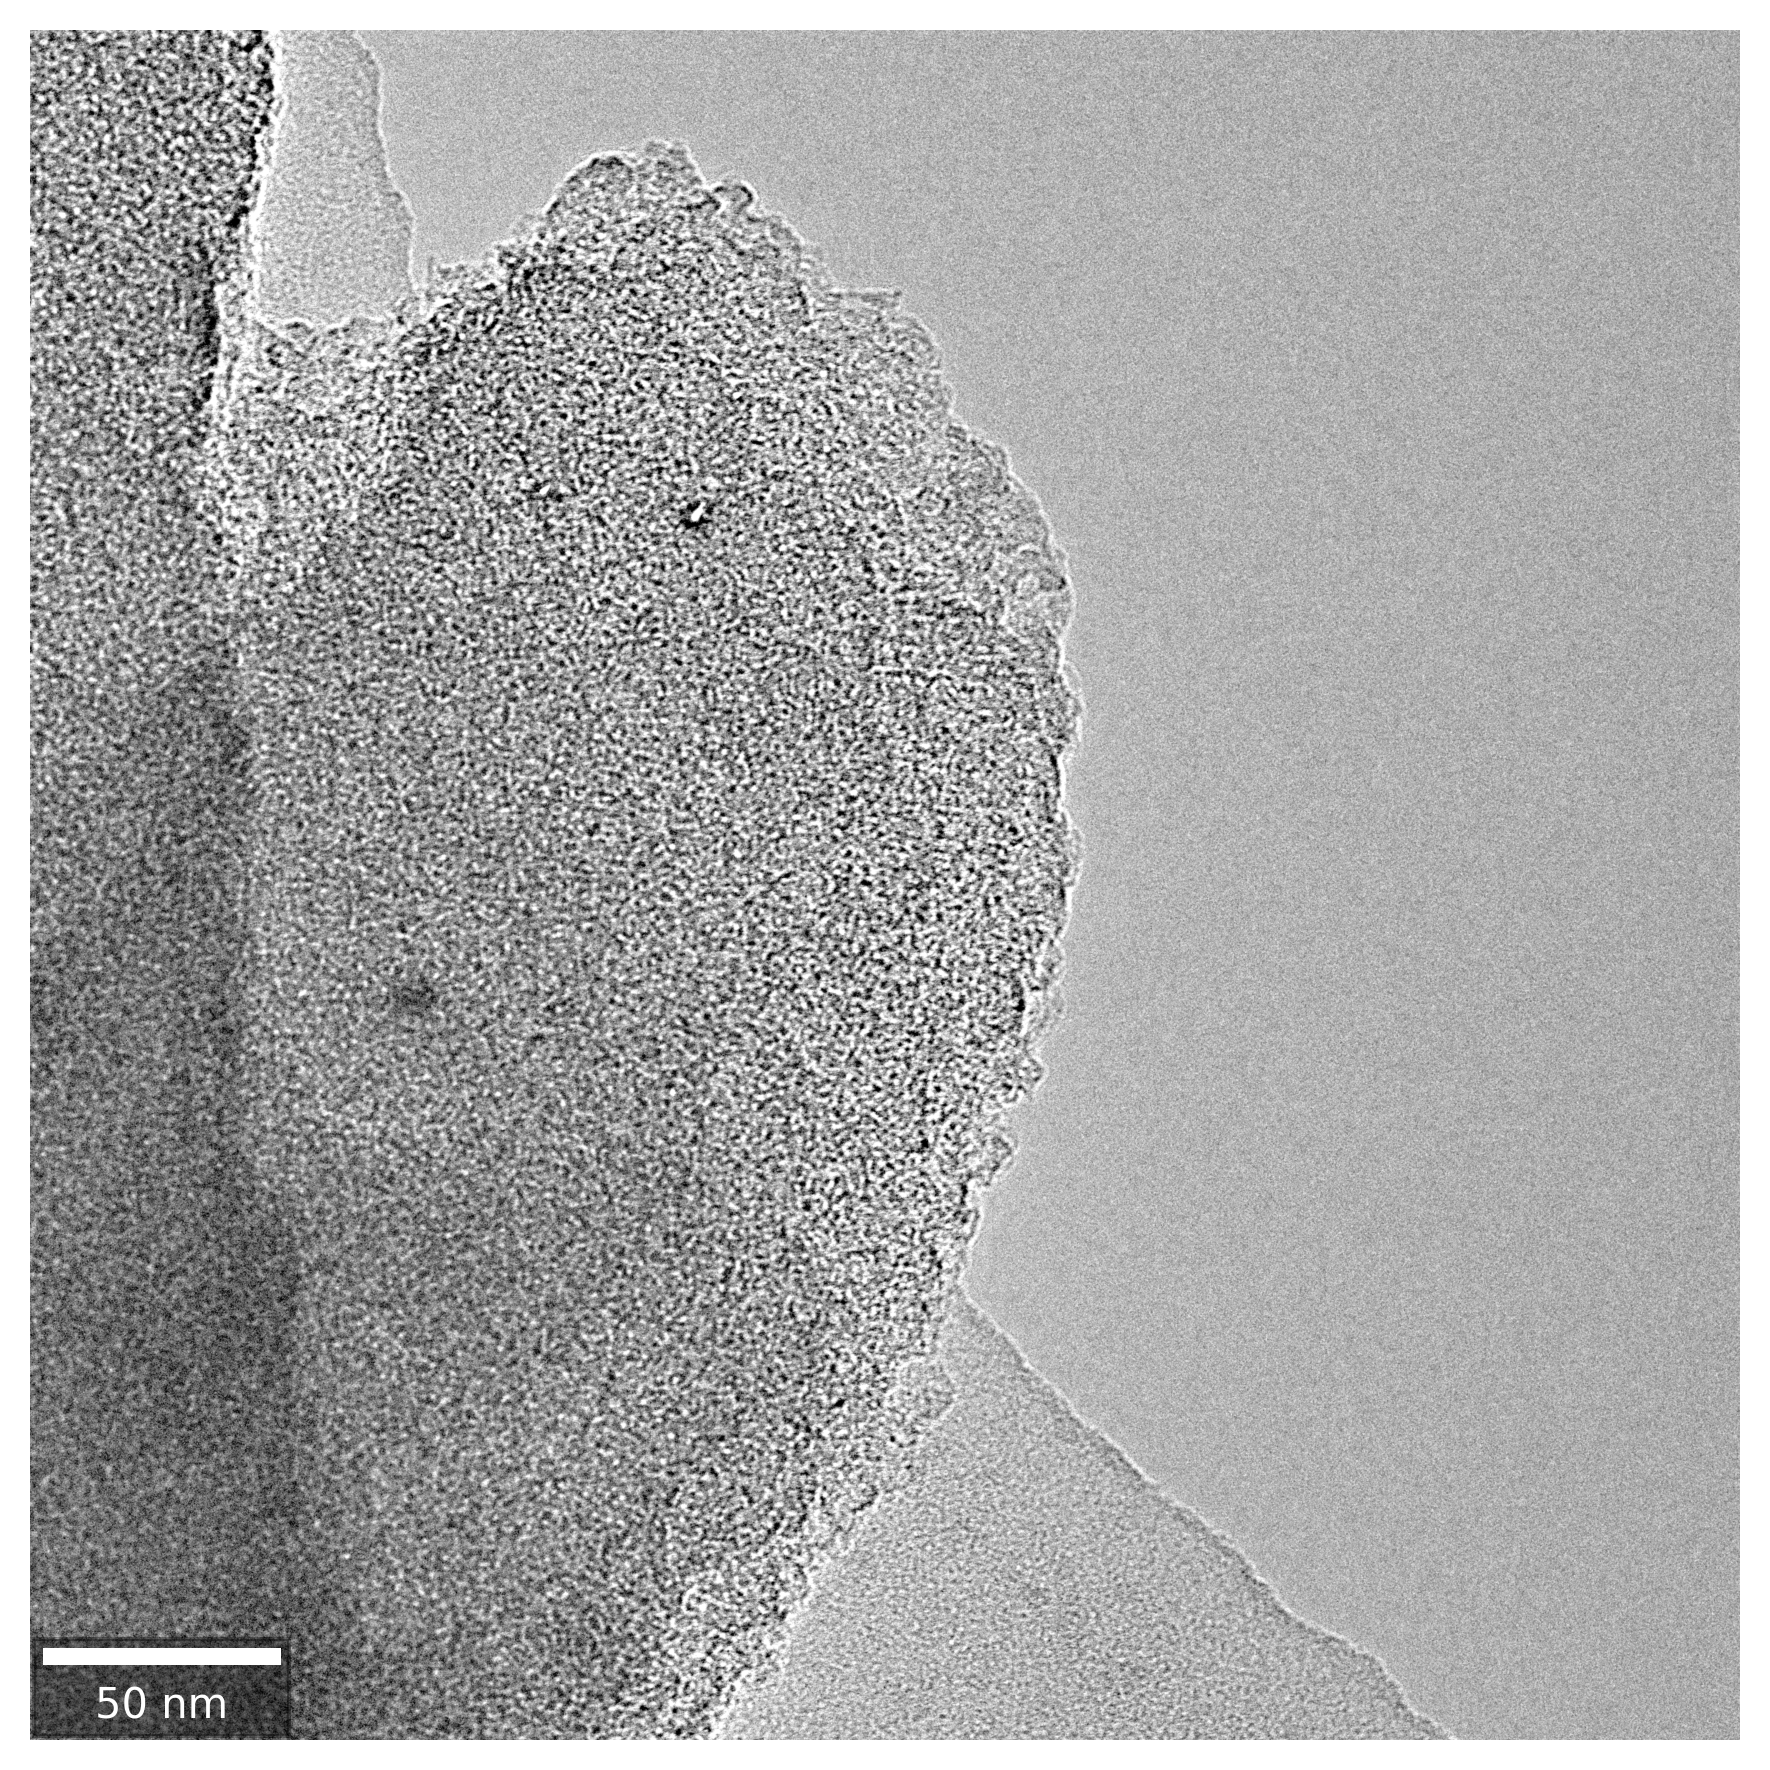

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from matplotlib_scalebar.scalebar import ScaleBar

def normalize_for_tiff(img, p_low=1, p_high=99, gamma=0.7, out_bits=8):
    img = np.asarray(img, dtype=np.float32)
    img = np.nan_to_num(img, nan=np.nanmedian(img), posinf=np.nanmax(img), neginf=np.nanmin(img))

    p1, p99 = np.percentile(img, (p_low, p_high))
    if p99 <= p1:
        raise ValueError(f"Bad percentile range: p1={p1}, p99={p99}")

    img = np.clip(img, p1, p99)
    img = (img - p1) / (p99 - p1)
    img = img ** gamma

    if out_bits == 8:
        return (img * 255).astype(np.uint8)
    if out_bits == 16:
        return (img * 65535).astype(np.uint16)
    raise ValueError("out_bits must be 8 or 16")


def get_dx_unit_from_hyperspy(signal):
    # Use x signal axis (not navigation axis)
    ax = signal.axes_manager.signal_axes[0]
    dx = float(ax.scale)
    unit = (ax.units or "px").strip()

    # Normalize units for scalebar
    if unit in ["m", "meter", "meters"]:
        return dx * 1e9, "nm"
    if unit in ["um", "µm"]:
        return dx * 1e3, "nm"
    return dx, unit


# ---- usage ----
img2d = np.asarray(data.data)
if img2d.ndim > 2:
    img2d = img2d[0]  # choose frame if stack

out8 = normalize_for_tiff(img2d, p_low=1, p_high=98, gamma=0.6, out_bits=8)

tifffile.imwrite("test_normalized_bright.tiff", out8)

dx, unit = get_dx_unit_from_hyperspy(data)
print("ScaleBar dx/unit:", dx, unit)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
ax.imshow(out8, cmap="gray")
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

scalebar = ScaleBar(
    dx, unit,
    location="lower left",
    length_fraction=0.2,
    color="white",
    box_color="black",
    box_alpha=0.35,
    frameon=True,
)
ax.add_artist(scalebar)

plt.tight_layout()
plt.show()
